# Position-precision sweep: standard IoU vs. GT=1-restricted IoU

Compares the 6 `boombox-position-precision-v2` runs (`scripts/boombox_position_precision.sh`:
coordconv, masked-conv decoder, pixelshuffle upsampling, non-local block, all four combined, and
the unmodified baseline) on two per-sample mask metrics, computed from each run's saved eval
predictions (`runs/<run>/outputs_history/eval/<split>/ep0500-*.pt`) against ground truth loaded
the same way the viz dashboard does (`viz.data.load_gt`).

**Metric A -- standard soft-IoU**: `sum(min(pred,gt)) / sum(max(pred,gt))` over the WHOLE grid
(32x32), i.e. this repo's usual IoU (see `utils/metrics.soft_iou`).

**Metric B -- IoU restricted to pixels where the ground truth equals 1**: same min/max formula,
but only summed over pixels where `gt == 1` exactly (the true-object footprint; this project's
masks are ~98% exactly binary, with a thin antialiased rim at object edges that `gt == 1`
deliberately excludes), instead of every pixel in the grid.

### Metric B is recall, not precision

Restricting the *domain* to `gt==1` pixels also restricts the union: every pixel in that domain
already has `gt=1`, so `max(pred, gt) = 1` everywhere in it (pred is a probability in `[0,1]`),
and `min(pred, gt) = pred`. So metric B collapses to

```
sum(pred over gt==1 pixels) / count(gt==1 pixels)  =  mean predicted probability on the true object
```

which is exactly **soft recall** (TP / (TP+FN) in the binary case: of every pixel that should be
foreground, what fraction did the model actually predict as foreground). It says nothing about
false positives outside the object -- that's what *precision* (restricting to `pred==1` pixels
instead) would measure. So: **metric B is IoU-recall**, not IoU-precision.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (str(ROOT), str(ROOT / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from viz.data import load_gt

%matplotlib inline

## Config

In [2]:
# ---- edit me ----------------------------------------------------------------
RUNS = [
    "pp-baseline-v2",
    "pp-coordconv-v2",
    "pp-maskedconv-v2",
    "pp-pixelshuffle-v2",
    "pp-nonlocal-v2",
    "pp-combo-v2",
]

LABELS = {
    "pp-baseline-v2": "baseline",
    "pp-coordconv-v2": "CoordConv",
    "pp-maskedconv-v2": "masked-conv decoder",
    "pp-pixelshuffle-v2": "PixelShuffle upsample",
    "pp-nonlocal-v2": "non-local block",
    "pp-combo-v2": "all 4 combined",
}
def label(run: str) -> str:
    return LABELS.get(run, run)

SPLITS = ["1-cube", "2-cubes", "3-cubes"]
EPOCH = 500          # all 6 runs were trained --max-duration 500ep
MASK_SHAPE = (32, 32)  # boombox's standardized output grid

EXPERIMENT = ROOT / "experiments" / "31_07_2026_gastronorm_exp1"
RUNS_DIR = ROOT / "runs"
# -----------------------------------------------------------------------------

## Load

Ground truth loads once (shared across runs). Predictions come straight from each run's saved
eval dumps -- `OutputSaver` writes `mask_pred` + `info.sample_id` per eval batch (see
`src/model/callbacks.py`); `mask_true` isn't saved (`DEFAULT_OUTPUT_KEYS`), so it's matched back
in here via `sample_id` against `gt.row_of`, the same join key the viz dashboard uses.

In [3]:
def load_run_split(run: str, split: str, epoch: int = EPOCH) -> tuple[np.ndarray, np.ndarray]:
    """(sample_ids, mask_pred) for one run/split/epoch, deduped by sample_id (last file wins)."""
    d = RUNS_DIR / run / "outputs_history" / ("train" if split == "train" else f"eval/{split}")
    files = sorted(d.glob(f"ep{epoch:04d}-ba*.pt"))
    if not files:
        return np.zeros(0, dtype=np.int64), np.zeros((0, *MASK_SHAPE), dtype=np.float32)
    ids, masks = [], []
    for p in files:
        obj = torch.load(p, map_location="cpu", weights_only=False)
        ids.append(np.asarray(obj["info"]["sample_id"]).reshape(-1).astype(np.int64))
        masks.append(obj["mask_pred"].float().numpy())
    ids = np.concatenate(ids)
    masks = np.concatenate(masks, axis=0)
    # last write wins for a repeated id (mirrors viz.data.load_run's dedupe)
    keep = {int(s): i for i, s in enumerate(ids)}
    order = sorted(keep.values())
    return ids[order], masks[order]


gt = load_gt(EXPERIMENT, *MASK_SHAPE)
print(f"ground truth: {len(gt)} samples, grid {gt.masks.shape[1]}x{gt.masks.shape[2]}")

# per (run, split): dict of per-sample arrays
per_sample: dict[tuple[str, str], dict[str, np.ndarray]] = {}

for run in RUNS:
    for split in SPLITS:
        ids, preds = load_run_split(run, split)
        if len(ids) == 0:
            print(f"  !! {run}/{split}: no predictions found")
            continue
        rows = np.array([gt.row_of.get(int(i), -1) for i in ids])
        ok = rows >= 0
        if not ok.all():
            print(f"  !! {run}/{split}: {(~ok).sum()}/{len(ok)} sample_ids missing from ground truth, dropped")
        preds, rows = preds[ok], rows[ok]
        target = gt.masks[rows]                        # (N,32,32), aligned to preds

        domain = target == 1.0                           # pixels where gt EQUALS 1 (excludes antialiased edges)
        inter_full = np.minimum(preds, target).sum(axis=(1, 2))
        union_full = np.maximum(preds, target).sum(axis=(1, 2))
        iou_full = np.where(union_full > 0, inter_full / np.clip(union_full, 1e-9, None), np.nan)

        inter_gt1 = np.where(domain, np.minimum(preds, target), 0).sum(axis=(1, 2))
        union_gt1 = np.where(domain, np.maximum(preds, target), 0).sum(axis=(1, 2))
        n_gt1 = domain.sum(axis=(1, 2))
        iou_gt1 = np.where(n_gt1 > 0, inter_gt1 / np.clip(union_gt1, 1e-9, None), np.nan)
        # sanity check: iou_gt1 should equal mean(pred over gt==1 pixels), per the derivation above
        recall_check = np.array([preds[i][domain[i]].mean() if n_gt1[i] > 0 else np.nan for i in range(len(preds))])
        assert np.allclose(iou_gt1[n_gt1 > 0], recall_check[n_gt1 > 0], atol=1e-5), "iou_gt1 != recall -- derivation broken"

        per_sample[(run, split)] = dict(iou_full=iou_full, iou_gt1=iou_gt1)
        print(f"  {label(run):24s} / {split:8s}: n={len(preds):4d}  "
              f"iou={np.nanmean(iou_full):.4f}  iou|gt=1(=recall)={np.nanmean(iou_gt1):.4f}")

ground truth: 3007 samples, grid 32x32
  baseline                 / 1-cube  : n= 112  iou=0.1924  iou|gt=1(=recall)=0.2443
  baseline                 / 2-cubes : n=  96  iou=0.2482  iou|gt=1(=recall)=0.3544
  baseline                 / 3-cubes : n=   8  iou=0.0817  iou|gt=1(=recall)=0.0874
  CoordConv                / 1-cube  : n= 112  iou=0.1825  iou|gt=1(=recall)=0.2403
  CoordConv                / 2-cubes : n=  96  iou=0.2628  iou|gt=1(=recall)=0.3790
  CoordConv                / 3-cubes : n=   8  iou=0.0962  iou|gt=1(=recall)=0.0966
  masked-conv decoder      / 1-cube  : n= 112  iou=0.0167  iou|gt=1(=recall)=0.0249
  masked-conv decoder      / 2-cubes : n=  96  iou=0.0184  iou|gt=1(=recall)=0.0176
  masked-conv decoder      / 3-cubes : n=   8  iou=0.0241  iou|gt=1(=recall)=0.0176
  PixelShuffle upsample    / 1-cube  : n= 112  iou=0.1619  iou|gt=1(=recall)=0.1973
  PixelShuffle upsample    / 2-cubes : n=  96  iou=0.2720  iou|gt=1(=recall)=0.3844
  PixelShuffle upsample    / 3-cubes 

## Summary table

In [4]:
rows = []
for run in RUNS:
    for split in SPLITS:
        d = per_sample.get((run, split))
        if d is None:
            continue
        rows.append(dict(run=label(run), split=split, n=len(d["iou_full"]),
                          iou=np.nanmean(d["iou_full"]),
                          iou_recall=np.nanmean(d["iou_gt1"])))
df = pd.DataFrame(rows)
df["run"] = pd.Categorical(df["run"], [label(r) for r in RUNS], ordered=True)
df["split"] = pd.Categorical(df["split"], SPLITS, ordered=True)
df = df.sort_values(["split", "run"]).reset_index(drop=True)
display(df.style.format({"iou": "{:.4f}", "iou_recall": "{:.4f}"}).hide(axis="index"))

run,split,n,iou,iou_recall
baseline,1-cube,112,0.1924,0.2443
CoordConv,1-cube,112,0.1825,0.2403
masked-conv decoder,1-cube,112,0.0167,0.0249
PixelShuffle upsample,1-cube,112,0.1619,0.1973
non-local block,1-cube,112,0.1605,0.2040
all 4 combined,1-cube,112,0.0385,0.0821
baseline,2-cubes,96,0.2482,0.3544
CoordConv,2-cubes,96,0.2628,0.3790
masked-conv decoder,2-cubes,96,0.0184,0.0176
PixelShuffle upsample,2-cubes,96,0.2720,0.3844


## Plot: standard IoU vs. IoU restricted to GT=1 (recall), grouped by split

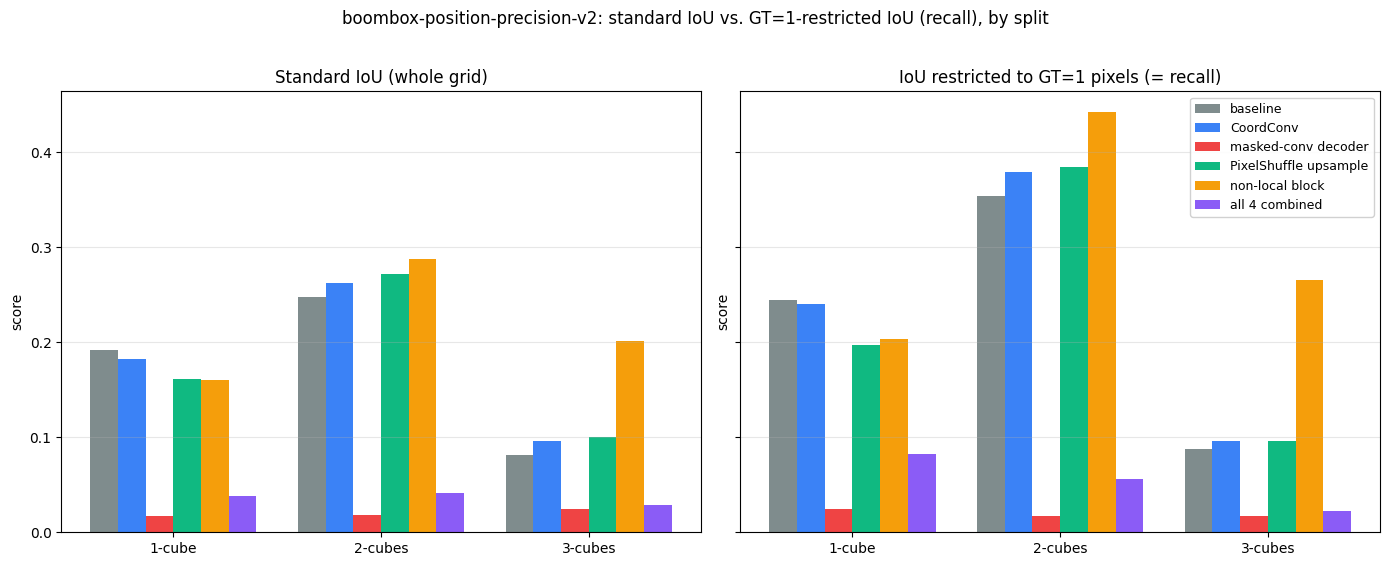

In [5]:
COLORS = {
    "baseline": "#7f8c8d", "CoordConv": "#3b82f6", "masked-conv decoder": "#ef4444",
    "PixelShuffle upsample": "#10b981", "non-local block": "#f59e0b", "all 4 combined": "#8b5cf6",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
metric_cols = [("iou", "Standard IoU (whole grid)"), ("iou_recall", "IoU restricted to GT=1 pixels (= recall)")]
run_labels = [label(r) for r in RUNS]
x = np.arange(len(SPLITS))
width = 0.8 / len(run_labels)

for ax, (col, title) in zip(axes, metric_cols):
    for i, rl in enumerate(run_labels):
        vals = [df[(df["run"] == rl) & (df["split"] == s)][col].squeeze() for s in SPLITS]
        vals = [v if np.isscalar(v) or v.size else np.nan for v in vals]
        ax.bar(x + (i - (len(run_labels) - 1) / 2) * width, vals, width,
               label=rl, color=COLORS.get(rl, None))
    ax.set_xticks(x)
    ax.set_xticklabels(SPLITS)
    ax.set_title(title)
    ax.set_ylabel("score")
    ax.grid(axis="y", alpha=0.3)

axes[1].legend(loc="upper right", fontsize=9, framealpha=0.9)
fig.suptitle("boombox-position-precision-v2: standard IoU vs. GT=1-restricted IoU (recall), by split", y=1.02)
fig.tight_layout()
plt.show()

## Connected components vs. `n_objects`

A third check: binarize `mask_pred` at some threshold, count connected components
(`scipy.ndimage.label`, default 4-connectivity), and compare that count to the sample's true
`n_objects` (from the saved eval batch's `info` dict -- the same field the training loop's count
head is supervised against).

**Dealing with the threshold**: `mask_pred` is a sigmoid probability map, and there's no single
"correct" binarization threshold baked into the model (loss is BCE/soft-IoU on the continuous
mask, not on a thresholded one) -- it's a free evaluation-time choice, and the right value can
differ per run since each run's predicted probabilities are calibrated differently. So instead of
picking one a priori, we **sweep it**: for every threshold in `[0.05, 0.95]`, binarize, count
components, and classify every sample as
- **correct** (green): predicted component count == `n_objects`
- **over-predicted** (red): predicted component count > `n_objects` (noise/fragmentation reading
  as extra objects)
- **under-predicted** (blue): predicted component count < `n_objects` (merged/missed objects)

then plot all three counts against threshold and mark the threshold that maximizes the number of
correct samples -- the best single operating point for this diagnostic, per run.

In [6]:
from scipy.ndimage import label as cc_label  # aliased: `label` already names the run-display-name helper above

def load_run_split_with_nobj(run: str, split: str, epoch: int = EPOCH):
    """(sample_ids, mask_pred, n_objects) for one run/split/epoch, deduped by sample_id."""
    d = RUNS_DIR / run / "outputs_history" / ("train" if split == "train" else f"eval/{split}")
    files = sorted(d.glob(f"ep{epoch:04d}-ba*.pt"))
    if not files:
        return (np.zeros(0, dtype=np.int64), np.zeros((0, *MASK_SHAPE), dtype=np.float32),
                np.zeros(0, dtype=np.int64))
    ids, masks, nobj = [], [], []
    for p in files:
        obj = torch.load(p, map_location="cpu", weights_only=False)
        ids.append(np.asarray(obj["info"]["sample_id"]).reshape(-1).astype(np.int64))
        masks.append(obj["mask_pred"].float().numpy())
        nobj.append(np.asarray(obj["info"]["n_objects"]).reshape(-1).astype(np.int64))
    ids, masks, nobj = np.concatenate(ids), np.concatenate(masks, axis=0), np.concatenate(nobj)
    keep = {int(s): i for i, s in enumerate(ids)}
    order = sorted(keep.values())
    return ids[order], masks[order], nobj[order]


# pool all 3 eval splits per run -- n_objects (1/2/3) comes from each sample's own info, not the
# split name, so pooling is safe and gives every run's threshold sweep more samples to work with
cc_data: dict[str, dict[str, np.ndarray]] = {}
for run in RUNS:
    masks_all, nobj_all = [], []
    for split in SPLITS:
        _, preds, nobj = load_run_split_with_nobj(run, split)
        masks_all.append(preds)
        nobj_all.append(nobj)
    cc_data[run] = dict(masks=np.concatenate(masks_all, axis=0), n_objects=np.concatenate(nobj_all))
    m = cc_data[run]
    nobj_vals = sorted(set(m["n_objects"].tolist()))
    print(f"  {label(run):24s}: n={len(m['masks']):4d}  n_objects values present: {nobj_vals}")

  baseline                : n= 216  n_objects values present: [1, 2, 3]
  CoordConv               : n= 216  n_objects values present: [1, 2, 3]
  masked-conv decoder     : n= 216  n_objects values present: [1, 2, 3]


  PixelShuffle upsample   : n= 216  n_objects values present: [1, 2, 3]
  non-local block         : n= 216  n_objects values present: [1, 2, 3]
  all 4 combined          : n= 216  n_objects values present: [1, 2, 3]


In [7]:
# mask_pred's useful range spans several orders of magnitude (min ~1e-19, and a naive linear
# sweep starting at 0.05 turned out to MISS the true optimum -- see markdown above: below ~5e-4
# noise creates dozens of spurious components (mean predicted count spikes to 6-20), and the
# correct-count curve actually peaks around 1e-3 to 5e-3, well below where a linear grid from 0.05
# would ever look. So: log-spaced from 1e-4 up to the linear region, then linear from 0.05 to 0.95.
THRESHOLDS = np.unique(np.concatenate([
    np.geomspace(1e-4, 0.05, 40),
    np.round(np.arange(0.05, 0.96, 0.02), 4),
]))

def component_counts(binary_masks: np.ndarray) -> np.ndarray:
    """binary_masks: (N,H,W) bool -> (N,) number of connected components per sample."""
    return np.array([cc_label(m)[1] for m in binary_masks])

cc_results: dict[str, pd.DataFrame] = {}
for run in RUNS:
    masks, nobj = cc_data[run]["masks"], cc_data[run]["n_objects"]
    rows = []
    for t in THRESHOLDS:
        n_pred = component_counts(masks >= t)
        correct = int((n_pred == nobj).sum())
        over = int((n_pred > nobj).sum())
        under = int((n_pred < nobj).sum())
        rows.append(dict(threshold=t, correct=correct, over=over, under=under))
    cc_results[run] = pd.DataFrame(rows)

best_threshold = {}
for run in RUNS:
    d = cc_results[run]
    i_best = d["correct"].idxmax()
    best_threshold[run] = (float(d.loc[i_best, "threshold"]), int(d.loc[i_best, "correct"]), len(cc_data[run]["masks"]))
    t, c, n = best_threshold[run]
    print(f"  {label(run):24s}: best threshold={t:.2f}  correct={c}/{n} ({c/n:.1%})")

  baseline                : best threshold=0.00  correct=153/216 (70.8%)
  CoordConv               : best threshold=0.01  correct=155/216 (71.8%)
  masked-conv decoder     : best threshold=0.00  correct=108/216 (50.0%)
  PixelShuffle upsample   : best threshold=0.00  correct=168/216 (77.8%)
  non-local block         : best threshold=0.00  correct=158/216 (73.1%)
  all 4 combined          : best threshold=0.00  correct=87/216 (40.3%)


## Plot: correct / over-predicted / under-predicted, as a stacked fraction of samples

Same three categories, now as a fraction of the run's total sample count (so every vertical
slice sums to 1) and drawn as a stacked area -- the continuous-x analog of a stacked bar chart --
so the three bands' cumulative extent is directly readable at every threshold.

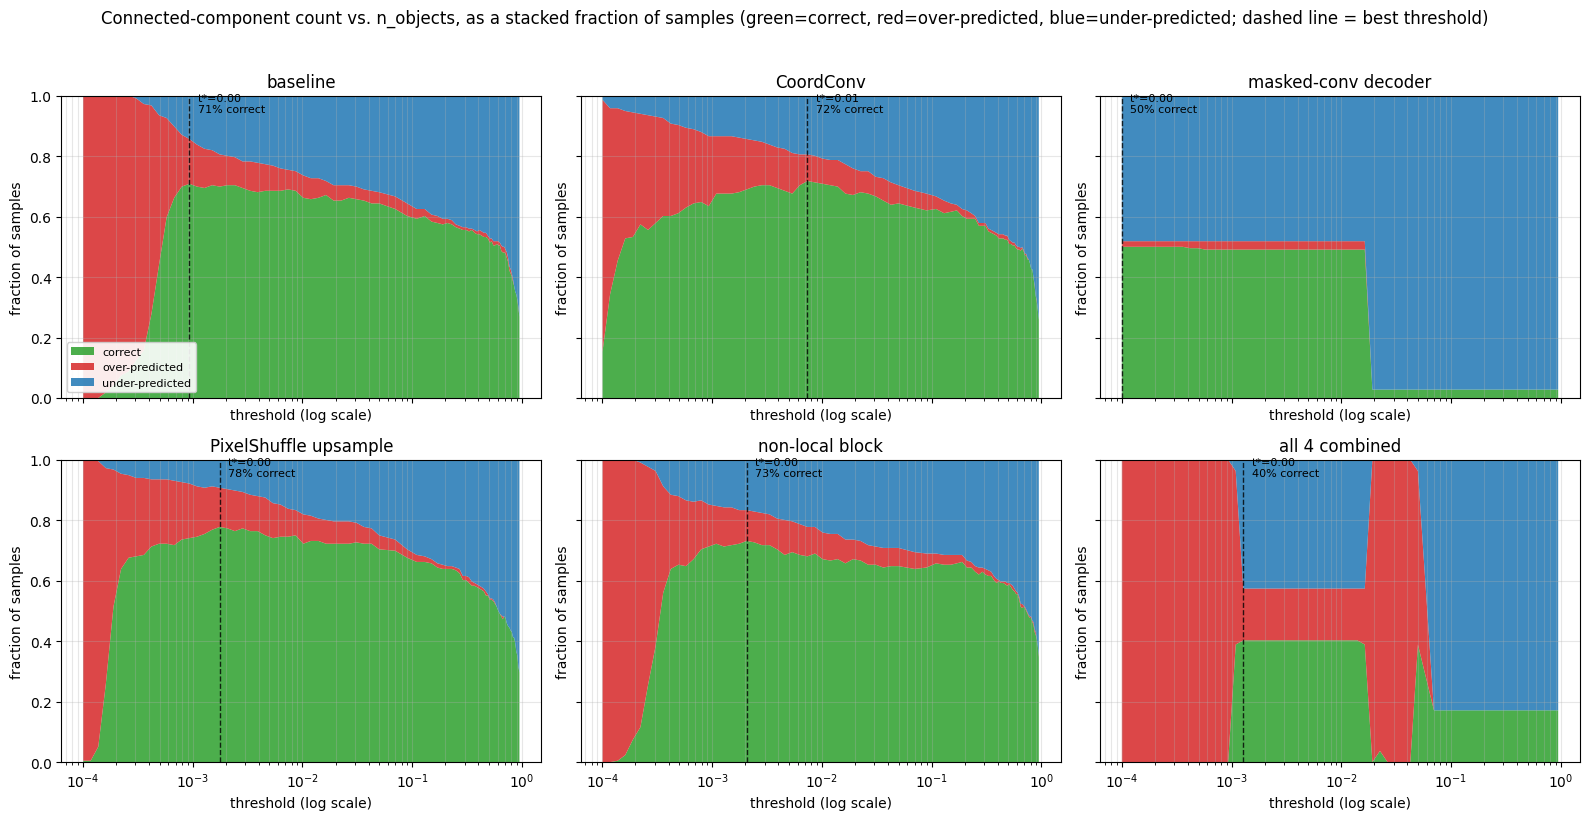

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)

for ax, run in zip(axes.flat, RUNS):
    d = cc_results[run]
    t_best, c_best, n = best_threshold[run]
    frac_correct, frac_over, frac_under = d["correct"] / n, d["over"] / n, d["under"] / n

    ax.stackplot(d["threshold"], frac_correct, frac_over, frac_under,
                 colors=["#2ca02c", "#d62728", "#1f77b4"],
                 labels=["correct", "over-predicted", "under-predicted"], alpha=0.85)
    ax.axvline(t_best, color="black", ls="--", lw=1, alpha=0.8)
    ax.annotate(f"t*={t_best:.2f}\n{c_best/n:.0%} correct", xy=(t_best, 1.0), xytext=(6, -12),
                textcoords="offset points", fontsize=8)
    ax.set_title(label(run))
    ax.set_xlabel("threshold (log scale)")
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_ylabel("fraction of samples")
    ax.grid(alpha=0.3, which="both")

axes.flat[0].legend(loc="lower left", fontsize=8, framealpha=0.9)
fig.suptitle("Connected-component count vs. n_objects, as a stacked fraction of samples "
             "(green=correct, red=over-predicted, blue=under-predicted; dashed line = best threshold)", y=1.02)
fig.tight_layout()
plt.show()